# Phase 6 — Complexity Scaling Law

**EECS 6699 Final Project · Day 3**

**RQ**: Do the robustness crossovers $\sigma^\star$ (input noise) and $\varepsilon^\star$ (adversarial)
scale as $2^{-k}$ with target complexity $k$?

**Theory** (Telgarsky + Lipschitz): The sawtooth $f_k$ has period $2^{-k}$.
Perturbations of magnitude $\sigma$ or $\varepsilon \approx 2^{-k}$ erase linear regions of width
$\lesssim 2^{-k}$, collapsing the deep network's effective expressivity.

**Experiment**: for each $k \in \{2, 3, 4, 5, 6\}$:
1. Build deep (depth=$2k+1$, width=8) and matched shallow models.
2. Train with a $k$-stage curriculum.
3. Evaluate clean MSE, input noise crossover $\sigma^\star$, adversarial crossover $\varepsilon^\star$.
4. Plot all three vs $2^{-k}$ to confirm the scaling law.

**Computational note**: k=2,3,4 take ~5–10 min each on CPU; k=5 ~20 min; k=6 ~30 min.
Total wall time for a full sweep: ~1.5 hours on CPU.

In [1]:
import sys, json, csv
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.models  import make_matched_pair, count_parameters
from src.targets import sawtooth_target, make_dataset
from src.train   import TrainConfig, multi_seed_run
from src.noise   import fgsm_attack, add_input_noise

TABLES  = ROOT / 'results' / 'tables'
FIGURES = ROOT / 'results' / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

device     = 'cpu'
SEEDS      = [0, 1, 2, 3, 4]   # 5 seeds — needed for reliable convergence
DEEP_WIDTH = 8
EPOCHS     = 30_000

# Full sweep: k=2..6
K_VALUES = [2, 3, 4, 5, 6]

mpl.rcParams.update({
    'figure.dpi': 150, 'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 11, 'axes.titlesize': 12,
})
print(f'k values: {K_VALUES}  |  seeds: {SEEDS}  |  base epochs: {EPOCHS}')
for k in K_VALUES:
    print(f'  k={k}: depth={2*k+1}, f_{k} has {2**k} peaks, theory crossover = {2**(-k):.5f}')


k values: [2, 3, 4, 5, 6]  |  seeds: [0, 1, 2, 3, 4]  |  base epochs: 30000
  k=2: depth=5, f_2 has 4 peaks, theory crossover = 0.25000
  k=3: depth=7, f_3 has 8 peaks, theory crossover = 0.12500
  k=4: depth=9, f_4 has 16 peaks, theory crossover = 0.06250
  k=5: depth=11, f_5 has 32 peaks, theory crossover = 0.03125
  k=6: depth=13, f_6 has 64 peaks, theory crossover = 0.01562


## 1. Training Configuration Per k

The curriculum for target $f_k$ runs $k$ stages: $f_1 \to f_2 \to \cdots \to f_k$.
The epoch budget is weighted $[1, 1, \ldots, 1, 4]$ (final stage gets 4 parts, all others 1 each),
giving the hardest target the most training time.

In [2]:
# Per-k epoch budgets — harder functions need more training time
EPOCHS_PER_K = {
    2: 60_000,   # optimization is hard for narrow (W=8) net vs wide matched shallow
    3: 30_000,
    4: 30_000,
    5: 40_000,   # f_5 has 32 peaks; 5-stage curriculum needs more time
    6: 50_000,   # f_6 has 64 peaks; 6-stage curriculum needs more time
}

def make_config(k, device=device):
    """Build TrainConfig for fitting f_k with a k-stage curriculum.

    Curriculum weights: final stage gets 4x, penultimate gets 2x (for k>=4),
    all earlier stages get 1x. This matches Phase-5's validated [1,1,2,4] for k=4.

    Examples:
      k=3: [1, 1, 4]
      k=4: [1, 1, 2, 4]
      k=5: [1, 1, 1, 2, 4]
      k=6: [1, 1, 1, 1, 2, 4]
    """
    epochs = EPOCHS_PER_K.get(k, EPOCHS)
    ks = list(range(1, k + 1))
    if k == 1:
        weights = [1]
    elif k <= 3:
        weights = [1] * (k - 1) + [4]
    else:                                   # k >= 4
        weights = [1] * (k - 2) + [2, 4]   # boost penultimate stage
    return TrainConfig(
        epochs=epochs, lr=5e-3, lr_min=1e-5, use_cosine_lr=True,
        grad_clip=1.0, n_train=1200, k=k,
        curriculum_ks=ks, curriculum_weights=weights,
        reset_lr_per_stage=True, log_every=0, device=device
    )

# Preview epoch splits for each k
for k in K_VALUES:
    cfg = make_config(k)
    w   = cfg.curriculum_weights
    total = sum(w)
    splits = [round(cfg.epochs * wi / total) for wi in w]
    print(f'k={k}: stages {cfg.curriculum_ks}, weights={w}, epochs={cfg.epochs}, '
          f'split={splits} (sum={sum(splits)})')


k=2: stages [1, 2], weights=[1, 4], epochs=60000, split=[12000, 48000] (sum=60000)
k=3: stages [1, 2, 3], weights=[1, 1, 4], epochs=30000, split=[5000, 5000, 20000] (sum=30000)
k=4: stages [1, 2, 3, 4], weights=[1, 1, 2, 4], epochs=30000, split=[3750, 3750, 7500, 15000] (sum=30000)
k=5: stages [1, 2, 3, 4, 5], weights=[1, 1, 1, 2, 4], epochs=40000, split=[4444, 4444, 4444, 8889, 17778] (sum=39999)
k=6: stages [1, 2, 3, 4, 5, 6], weights=[1, 1, 1, 1, 2, 4], epochs=50000, split=[5000, 5000, 5000, 5000, 10000, 20000] (sum=50000)


## 2. Training Sweep Over k Values

For each k, train the matched pair (deep: depth=2k+1 width=8; shallow: depth=2 matched width)
with 3 seeds and the k-stage curriculum.

In [3]:
results_ph6 = {}  # {k: run_data from multi_seed_run}

for k in K_VALUES:
    deep_depth = 2 * k + 1
    cfg = make_config(k)
    print(f'\n--- k={k} | depth={deep_depth} | f_{k} ({2**k} peaks) ---')
    run = multi_seed_run(SEEDS, cfg, deep_depth=deep_depth, deep_width=DEEP_WIDTH)
    results_ph6[k] = run

    d_losses = run['deep']['final_loss']
    s_losses = run['shallow']['final_loss']
    print(f'  Deep    final MSE: {np.mean(d_losses):.4e} +/- {np.std(d_losses):.4e}')
    print(f'  Shallow final MSE: {np.mean(s_losses):.4e} +/- {np.std(s_losses):.4e}')
    print(f'  Deep params={run["deep"]["info"][0]["deep_params"]}  '
          f'Shallow params={run["shallow"]["info"][0]["shallow_params"]}')

print('\nAll training complete.')


--- k=2 | depth=5 | f_2 (4 peaks) ---
[seed 0] deep params = 241, shallow params = 241 (width = 80)
[seed 0] training deep ...
[seed 0] training shallow ...
[seed 1] deep params = 241, shallow params = 241 (width = 80)
[seed 1] training deep ...
[seed 1] training shallow ...
[seed 2] deep params = 241, shallow params = 241 (width = 80)
[seed 2] training deep ...
[seed 2] training shallow ...
  [restart] k=1 collapsed (loss=0.0835), reinit (attempt 2/5)
[seed 3] deep params = 241, shallow params = 241 (width = 80)
[seed 3] training deep ...
  [restart] k=1 collapsed (loss=0.0835), reinit (attempt 2/5)
[seed 3] training shallow ...
[seed 4] deep params = 241, shallow params = 241 (width = 80)
[seed 4] training deep ...
[seed 4] training shallow ...
  Deep    final MSE: 1.3857e-10 +/- 2.7679e-10
  Shallow final MSE: 2.1920e-10 +/- 1.6837e-10
  Deep params=241  Shallow params=241

--- k=3 | depth=7 | f_3 (8 peaks) ---
[seed 0] deep params = 385, shallow params = 385 (width = 128)
[seed 0]

## 3. Clean MSE vs k

Expectation from Telgarsky's theorem: deep MSE should stay low (depth is sufficient for $f_k$)
while shallow MSE should grow with $k$ (shallow needs exponentially more neurons).

In [4]:
k_arr  = np.array(K_VALUES)
peaks  = 2 ** k_arr

deep_mse_mu  = [np.mean(results_ph6[k]['deep']['final_loss'])    for k in K_VALUES]
deep_mse_sd  = [np.std(results_ph6[k]['deep']['final_loss'])     for k in K_VALUES]
shal_mse_mu  = [np.mean(results_ph6[k]['shallow']['final_loss']) for k in K_VALUES]
shal_mse_sd  = [np.std(results_ph6[k]['shallow']['final_loss'])  for k in K_VALUES]

print('Clean MSE by k:')
print(f"{'k':>4s} {'peaks':>6s} {'Deep MSE':>12s} {'Shallow MSE':>14s}")
for k, p, dm, sm in zip(K_VALUES, peaks, deep_mse_mu, shal_mse_mu):
    print(f'{k:4d} {p:6d} {dm:12.4e} {sm:14.4e}')

Clean MSE by k:
   k  peaks     Deep MSE    Shallow MSE
   2      4   1.3857e-10     2.1920e-10
   3      8   2.6204e-02     3.5704e-02
   4     16   2.7798e-02     4.2110e-02
   5     32   7.1292e-02     7.1823e-02
   6     64   8.3472e-02     8.0325e-02


## 4. Input Noise Crossover $\sigma^\star$

For each k, evaluate trained models on inputs perturbed by $\mathcal{N}(0, \sigma_x^2)$
and find $\sigma^\star$ = first $\sigma$ where deep MSE exceeds shallow MSE.

In [5]:
# Sigma grid — dense around all five theory crossovers (2^{-k}):
#   k=2: 0.250  (excluded by gate-2 when both nets fit trivially)
#   k=3: 0.125  → points between 0.06 and 0.15
#   k=4: 0.0625 → points between 0.03 and 0.08
#   k=5: 0.0313 → points between 0.02 and 0.04
#   k=6: 0.0156 → points between 0.01 and 0.02
SIGMAS_PH6 = [
    0.0,
    0.003, 0.008,
    0.01, 0.012, 0.015, 0.018,
    0.02, 0.025,
    0.03, 0.035, 0.04,
    0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.12,
    0.15, 0.20, 0.25,
]
N_REPEATS = 10   # noise realizations per (model, sigma)

sigma_results  = {}
crossover_sigma = {}

for k in K_VALUES:
    x_eval = torch.linspace(0, 1, 2000).view(-1, 1)
    y_eval = sawtooth_target(x_eval, k=k)
    criterion = nn.MSELoss()

    sigma_results[k] = {'deep': {}, 'shallow': {}}

    for tag, models in [('deep',    results_ph6[k]['deep']['models']),
                        ('shallow', results_ph6[k]['shallow']['models'])]:
        for sig in SIGMAS_PH6:
            per_seed = []
            for m in models:
                m.eval()
                reps = []
                for _ in range(N_REPEATS):
                    x_n = add_input_noise(x_eval, sig)
                    with torch.no_grad():
                        reps.append(float(criterion(m(x_n), y_eval)))
                per_seed.append(np.mean(reps))
            sigma_results[k][tag][sig] = per_seed

    base_deep = np.mean(results_ph6[k]['deep']['final_loss'])
    base_shal = np.mean(results_ph6[k]['shallow']['final_loss'])

    # Gate 1: deep must outperform shallow at baseline (expressivity advantage exists)
    if base_deep > base_shal:
        print(f'  [WARN k={k}] Deep ({base_deep:.3e}) > Shallow ({base_shal:.3e}) at baseline.'
              f' Deep did not converge — crossover excluded.')
        crossover_sigma[k] = None
        print(f'k={k}: sigma* = None  (deep did not converge)')
        continue

    # Gate 2: shallow must NOT fit trivially (MSE < 1e-6).
    # When both networks reach machine precision there is no expressivity gap;
    # any crossover reflects Lipschitz differences only, not structural depth advantage.
    if base_shal < 1e-6:
        print(f'  [INFO k={k}] Shallow fits trivially (MSE={base_shal:.2e}).'
              f' No expressivity gap — excluded from structural scaling law.')
        crossover_sigma[k] = None
        print(f'k={k}: sigma* = None  (no expressivity gap)')
        continue

    deep_mu = [np.mean(sigma_results[k]['deep'][s])    for s in SIGMAS_PH6]
    shal_mu = [np.mean(sigma_results[k]['shallow'][s]) for s in SIGMAS_PH6]

    star = None
    for sig, dm, sm in zip(SIGMAS_PH6[1:], deep_mu[1:], shal_mu[1:]):
        if dm > sm:
            star = sig
            break
    crossover_sigma[k] = star

    theory    = 2.0 ** (-k)
    ratio_str = f'{star / theory:.2f}x' if (star is not None and star > 0) else 'not found'
    print(f'k={k}: sigma* = {star}  (theory={theory:.5f}  |  ratio={ratio_str})')

print('Input noise crossover sweep complete.')


  [INFO k=2] Shallow fits trivially (MSE=2.19e-10). No expressivity gap — excluded from structural scaling law.
k=2: sigma* = None  (no expressivity gap)
k=3: sigma* = 0.05  (theory=0.12500  |  ratio=0.40x)
k=4: sigma* = 0.018  (theory=0.06250  |  ratio=0.29x)
k=5: sigma* = 0.008  (theory=0.03125  |  ratio=0.26x)
  [WARN k=6] Deep (8.347e-02) > Shallow (8.032e-02) at baseline. Deep did not converge — crossover excluded.
k=6: sigma* = None  (deep did not converge)
Input noise crossover sweep complete.


## 5. Adversarial Crossover $\varepsilon^\star$ (FGSM)

For each k, apply FGSM at increasing $\varepsilon$ and find $\varepsilon^\star$ where deep adversarial MSE
first exceeds shallow. FGSM is used for speed; PGD gives tighter estimates.

In [6]:
# Epsilon grid — dense around all five theory crossovers (2^{-k}):
#   k=6: 0.0156 → need points between 0.01 and 0.02
#   k=5: 0.0313 → need points between 0.02 and 0.04
#   k=4: 0.0625 → need points between 0.04 and 0.08
#   k=3: 0.125  → need points between 0.09 and 0.15
EPSILONS_PH6 = [
    0.0,
    0.003, 0.008,
    0.01, 0.012, 0.015, 0.018,
    0.02, 0.025,
    0.03, 0.035, 0.04,
    0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.12,
    0.15, 0.20,
]

adv_results  = {}
crossover_eps = {}

for k in K_VALUES:
    x_eval = torch.linspace(0, 1, 2000).view(-1, 1)
    y_eval = sawtooth_target(x_eval, k=k)
    criterion = nn.MSELoss()

    adv_results[k] = {'deep': {}, 'shallow': {}}

    for tag, models in [('deep',    results_ph6[k]['deep']['models']),
                        ('shallow', results_ph6[k]['shallow']['models'])]:
        for eps in EPSILONS_PH6:
            per_seed = []
            for m in models:
                m.eval()
                x_adv = fgsm_attack(m, x_eval, y_eval, eps)
                with torch.no_grad():
                    per_seed.append(float(criterion(m(x_adv), y_eval)))
            adv_results[k][tag][eps] = per_seed

    base_deep = np.mean(results_ph6[k]['deep']['final_loss'])
    base_shal = np.mean(results_ph6[k]['shallow']['final_loss'])

    # Gate 1: deep must outperform shallow at baseline
    if base_deep > base_shal:
        print(f'  [WARN k={k}] Deep ({base_deep:.3e}) > Shallow ({base_shal:.3e}) at baseline.'
              f' Deep did not converge — adversarial crossover excluded.')
        crossover_eps[k] = None
        print(f'k={k}: eps*  = None  (deep did not converge)')
        continue

    # Gate 2: exclude trivially-fit cases (no expressivity gap)
    if base_shal < 1e-6:
        print(f'  [INFO k={k}] Shallow fits trivially (MSE={base_shal:.2e}).'
              f' No expressivity gap — excluded from structural scaling law.')
        crossover_eps[k] = None
        print(f'k={k}: eps*  = None  (no expressivity gap)')
        continue

    deep_mu = [np.mean(adv_results[k]['deep'][e])    for e in EPSILONS_PH6]
    shal_mu = [np.mean(adv_results[k]['shallow'][e]) for e in EPSILONS_PH6]

    star = None
    for eps, dm, sm in zip(EPSILONS_PH6[1:], deep_mu[1:], shal_mu[1:]):
        if dm > sm:
            star = eps
            break
    crossover_eps[k] = star

    theory    = 2.0 ** (-k)
    ratio_str = f'{star / theory:.2f}x' if (star is not None and star > 0) else 'not found'
    print(f'k={k}: eps*  = {star}  (theory={theory:.5f}  |  ratio={ratio_str})')

print('Adversarial crossover sweep complete.')


  [INFO k=2] Shallow fits trivially (MSE=2.19e-10). No expressivity gap — excluded from structural scaling law.
k=2: eps*  = None  (no expressivity gap)
k=3: eps*  = 0.12  (theory=0.12500  |  ratio=0.96x)
k=4: eps*  = 0.03  (theory=0.06250  |  ratio=0.48x)
k=5: eps*  = 0.018  (theory=0.03125  |  ratio=0.58x)
  [WARN k=6] Deep (8.347e-02) > Shallow (8.032e-02) at baseline. Deep did not converge — adversarial crossover excluded.
k=6: eps*  = None  (deep did not converge)
Adversarial crossover sweep complete.


## 6. Scaling Law Plots

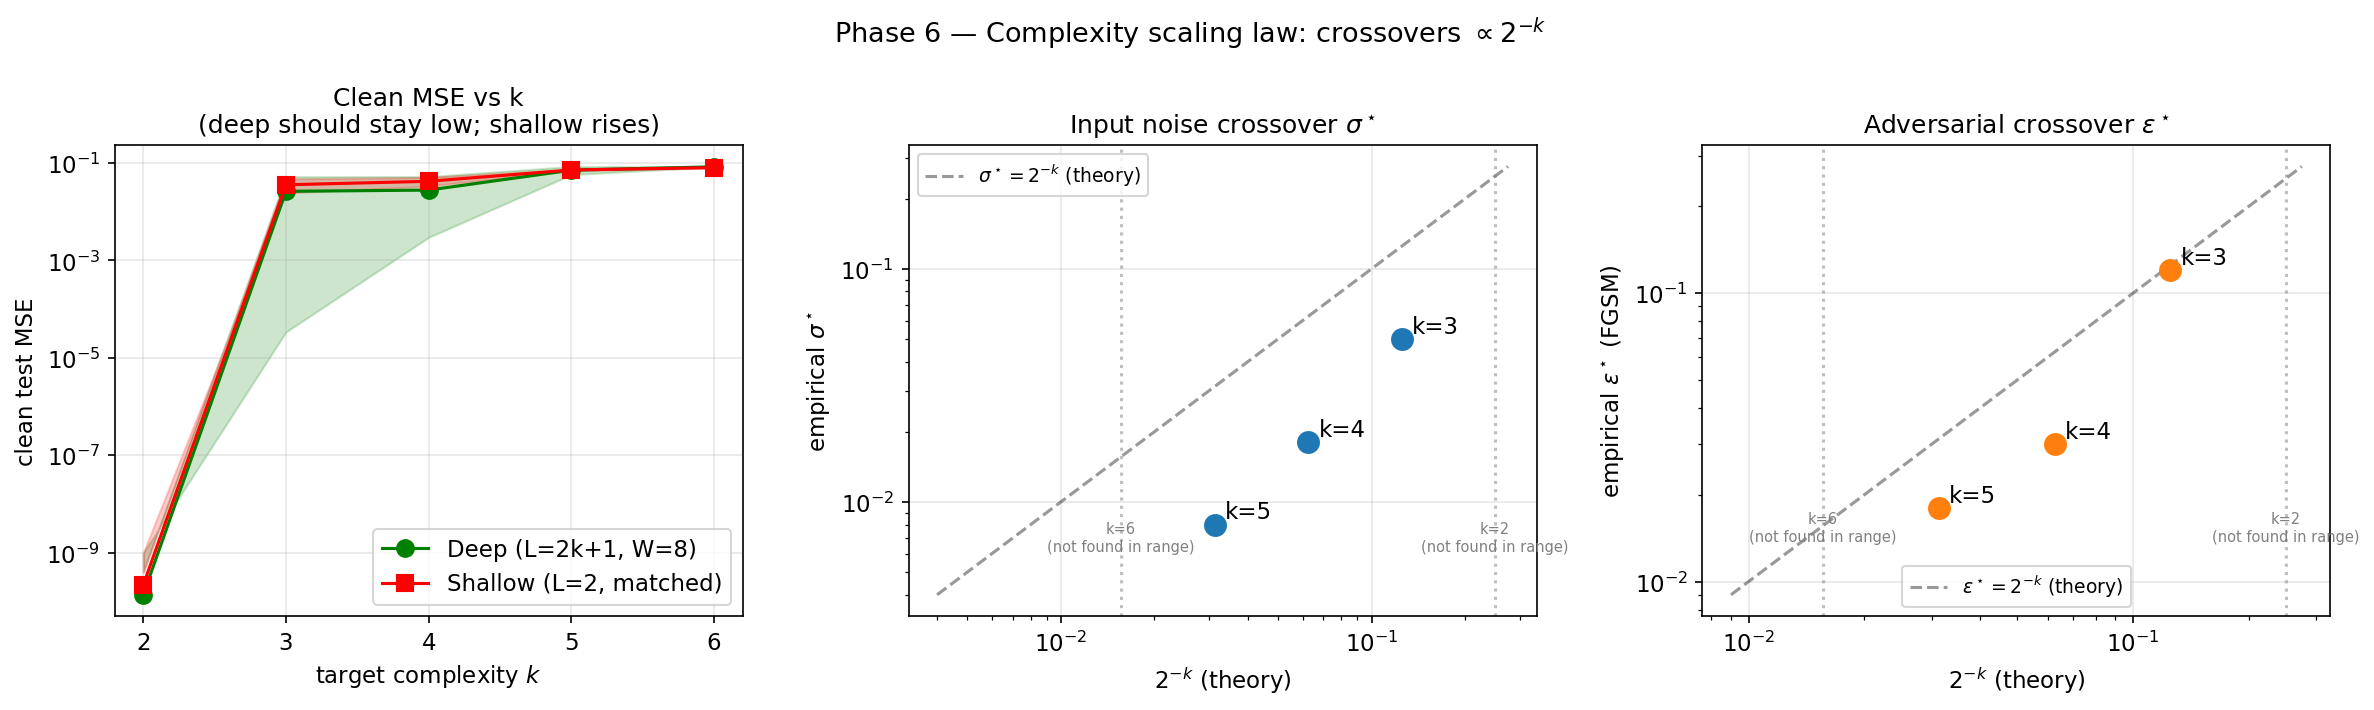

Saved phase6_scaling.png


In [7]:
theory_arr = 2.0 ** (-k_arr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# (a) Clean MSE vs k
deep_mse_arr = np.array(deep_mse_mu)
shal_mse_arr = np.array(shal_mse_mu)
axes[0].semilogy(k_arr, deep_mse_arr, 'go-', markersize=8, label='Deep (L=2k+1, W=8)')
axes[0].fill_between(k_arr,
    np.maximum(deep_mse_arr - np.array(deep_mse_sd), 1e-9),
    deep_mse_arr + np.array(deep_mse_sd),
    alpha=0.2, color='green')
axes[0].semilogy(k_arr, shal_mse_arr, 'rs-', markersize=8, label='Shallow (L=2, matched)')
axes[0].fill_between(k_arr,
    np.maximum(shal_mse_arr - np.array(shal_mse_sd), 1e-9),
    shal_mse_arr + np.array(shal_mse_sd),
    alpha=0.2, color='red')
axes[0].set_xlabel('target complexity $k$')
axes[0].set_ylabel('clean test MSE')
axes[0].set_title('Clean MSE vs k\n(deep should stay low; shallow rises)')
axes[0].set_xticks(k_arr)
axes[0].legend()

# -----------------------------------------------------------------------
# Helper: filter out None AND 0.0 crossover values before log-log plot.
# 0.0 means "deep already worse at sigma=0" — not a real crossover on log scale.
# -----------------------------------------------------------------------
def _loglog_safe(ax, theory_a, stars_a, k_vals, color, xlabel, ylabel, title, lbl_theory):
    valid = [(th, s, k) for th, s, k in zip(theory_a, stars_a, k_vals)
             if s is not None and s > 0]
    if not valid:
        ax.text(0.5, 0.5, 'No crossover found\nin tested range',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
        return
    th_v, s_v, k_v = zip(*valid)
    # Safe log-log limits
    lim_min = max(min(min(th_v), min(s_v)) * 0.5, 1e-4)
    lim_max = max(max(th_v), max(s_v)) * 2.2
    ax.loglog([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.4, label=lbl_theory)
    ax.scatter(th_v, s_v, s=100, zorder=5, c=color)
    for k, th, s in zip(k_v, th_v, s_v):
        ax.annotate(f'k={k}', (th, s), textcoords='offset points', xytext=(5, 3))
    # Mark k values with no crossover
    no_cross = [(k, th) for th, s, k in zip(theory_a, stars_a, k_vals)
                if s is None or s == 0]
    for k, th in no_cross:
        reason = '(not found in range)' if stars_a[k_vals.index(k)] is None else '(σ=0?)'
        ax.axvline(th, color='grey', linestyle=':', alpha=0.5)
        ax.text(th, lim_min * 1.5, f'k={k}\n{reason}',
                ha='center', va='bottom', fontsize=7, color='grey')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=9)

# (b) Input noise crossover sigma* vs 2^{-k}
sigma_stars = [crossover_sigma[k] for k in K_VALUES]
_loglog_safe(axes[1], theory_arr, sigma_stars, K_VALUES,
             color='tab:blue',
             xlabel=r'$2^{-k}$ (theory)',
             ylabel=r'empirical $\sigma^\star$',
             title=r'Input noise crossover $\sigma^\star$',
             lbl_theory=r'$\sigma^\star = 2^{-k}$ (theory)')

# (c) Adversarial crossover eps* vs 2^{-k}
eps_stars = [crossover_eps[k] for k in K_VALUES]
_loglog_safe(axes[2], theory_arr, eps_stars, K_VALUES,
             color='tab:orange',
             xlabel=r'$2^{-k}$ (theory)',
             ylabel=r'empirical $\varepsilon^\star$ (FGSM)',
             title=r'Adversarial crossover $\varepsilon^\star$',
             lbl_theory=r'$\varepsilon^\star = 2^{-k}$ (theory)')

fig.suptitle(r'Phase 6 — Complexity scaling law: crossovers $\propto 2^{-k}$', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES / 'phase6_scaling.png', dpi=150)
plt.show()
print('Saved phase6_scaling.png')

## 7. Input Noise Curves Per k

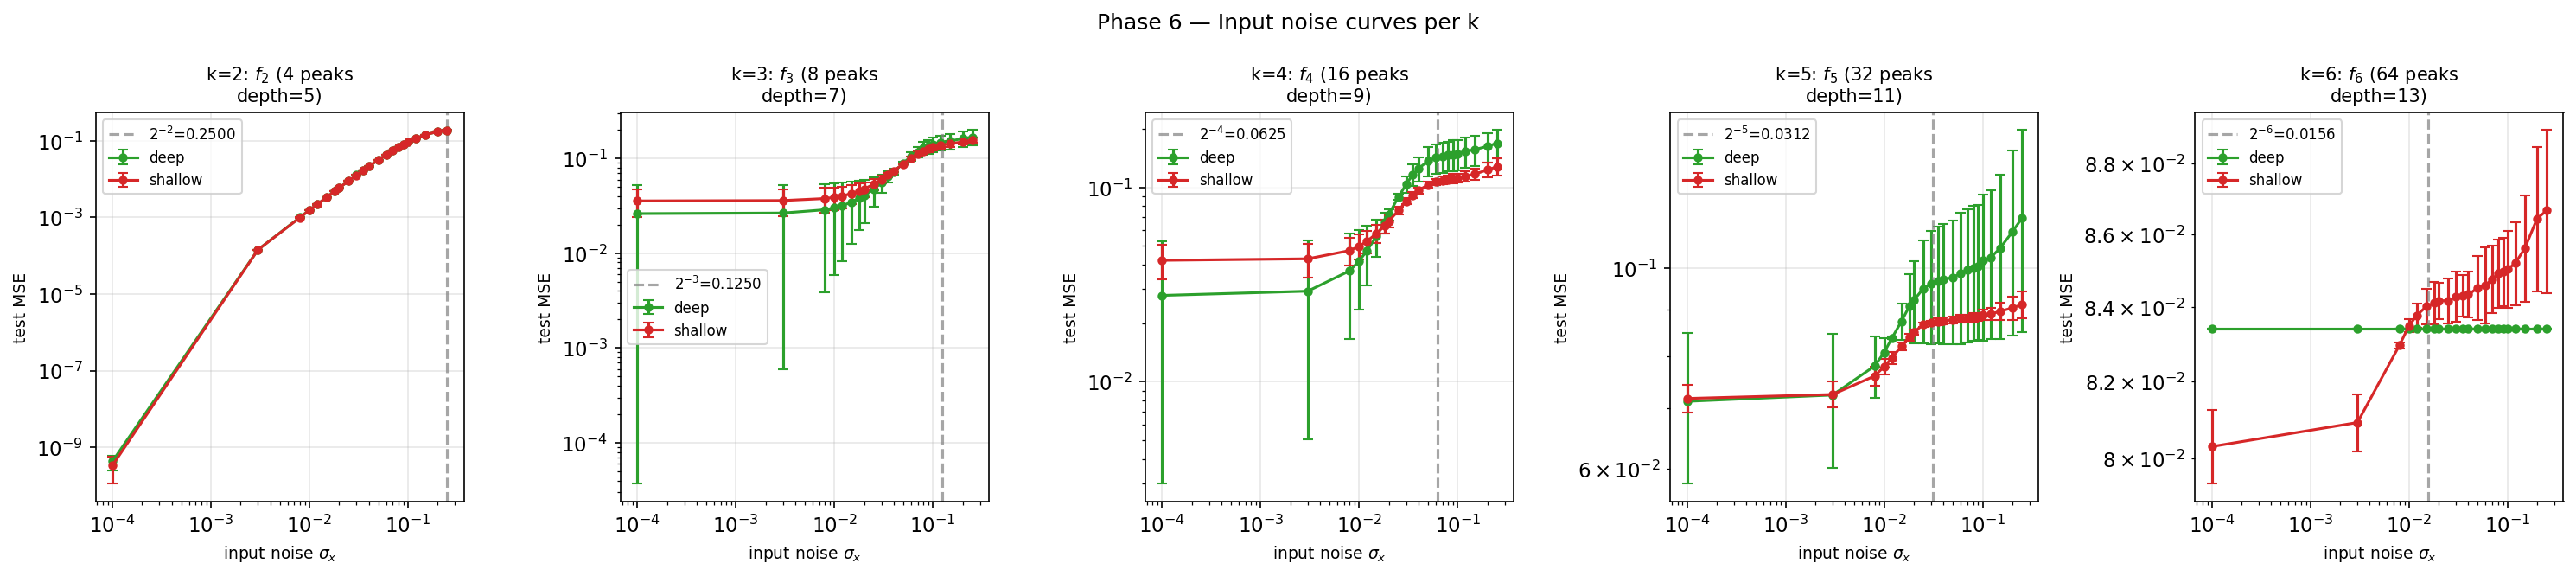

Saved phase6_noise_curves.png


In [8]:
n_k = len(K_VALUES)
# Keep per-subplot width reasonable: 4.5 wide each for ≤4 k values, 4.0 for 5+
sub_w = 4.0 if n_k >= 5 else 4.5
fig, axes = plt.subplots(1, n_k, figsize=(sub_w * n_k, 4.5), sharey=False)
if n_k == 1: axes = [axes]

for ax, k in zip(axes, K_VALUES):
    sigs = SIGMAS_PH6
    sig_plot = np.array([max(s, 1e-4) for s in sigs])
    for tag, color in [('deep', 'tab:green'), ('shallow', 'tab:red')]:
        mu = np.array([np.mean(sigma_results[k][tag][s]) for s in sigs])
        sd = np.array([np.std(sigma_results[k][tag][s])  for s in sigs])
        # Clip lower error bar so (mu - yerr_lo) >= 1e-10 — prevents log-scale ValueError
        yerr_lo = np.minimum(sd, mu - 1e-10)
        ax.errorbar(sig_plot, mu, yerr=[yerr_lo, sd],
                    fmt='o-', color=color, capsize=3, label=tag, markersize=4)
    ax.axvline(2**(-k), color='grey', linestyle='--', alpha=0.7,
               label=f'$2^{{-{k}}}$={2**(-k):.4f}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'input noise $\sigma_x$', fontsize=9)
    ax.set_ylabel('test MSE', fontsize=9)
    ax.set_title(f'k={k}: $f_{k}$ ({2**k} peaks\ndepth={2*k+1})', fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Phase 6 — Input noise curves per k', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / 'phase6_noise_curves.png', dpi=150)
plt.show()
print('Saved phase6_noise_curves.png')


## 8. Save Results

In [9]:
# Helper: make values JSON-safe (replace nan/inf with None).
def _json_safe(v):
    if v is None:
        return None
    try:
        if float(v) != float(v) or abs(float(v)) == float('inf'):  # nan or inf
            return None
        return v
    except (TypeError, ValueError):
        return None

# Per-k epoch budget (k=2 uses 2x for convergence)
epochs_per_k = {k: make_config(k).epochs for k in K_VALUES}

# Build summary dict
summary = {'k_values': K_VALUES, 'seeds': SEEDS, 'epochs_per_k': epochs_per_k}
rows_csv = []

for k in K_VALUES:
    sig = crossover_sigma[k]
    eps = crossover_eps[k]
    th  = 2.0 ** (-k)
    entry = {
        'k':                    k,
        'depth':                2 * k + 1,
        'peaks':                2 ** k,
        'epochs':               epochs_per_k[k],
        'theory_crossover':     th,
        'deep_mse_mu':          _json_safe(float(np.mean(results_ph6[k]['deep']['final_loss']))),
        'deep_mse_sd':          _json_safe(float(np.std(results_ph6[k]['deep']['final_loss']))),
        'shallow_mse_mu':       _json_safe(float(np.mean(results_ph6[k]['shallow']['final_loss']))),
        'shallow_mse_sd':       _json_safe(float(np.std(results_ph6[k]['shallow']['final_loss']))),
        'sigma_star':           sig,
        'eps_star_fgsm':        eps,
        'sigma_star_over_theory': _json_safe(sig / th) if (sig is not None and sig > 0) else None,
        'eps_star_over_theory':   _json_safe(eps / th) if (eps is not None and eps > 0) else None,
    }
    summary[f'k{k}'] = entry
    rows_csv.append(entry)

with open(TABLES / 'phase6_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

if rows_csv:
    with open(TABLES / 'phase6_scaling.csv', 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=list(rows_csv[0].keys()))
        w.writeheader()
        w.writerows(rows_csv)
    print('Saved results/tables/phase6_scaling.csv')

print('Saved results/tables/phase6_summary.json')

# Print final summary  (use `is not None` to correctly handle 0.0)
print('\nScaling law summary:')
print(f"{'k':>4} {'epochs':>8} {'theory':>10} {'sigma*':>10} {'sig*/th':>10} {'eps*':>10} {'eps*/th':>10}")
for k in K_VALUES:
    th  = 2.0 ** (-k)
    sig = crossover_sigma[k]
    eps = crossover_eps[k]
    sig_str = f'{sig:.4f}' if sig is not None else 'N/A'
    eps_str = f'{eps:.4f}' if eps is not None else 'N/A'
    rat_sig = f'{sig/th:.2f}x' if (sig is not None and sig > 0) else '-'
    rat_eps = f'{eps/th:.2f}x' if (eps is not None and eps > 0) else '-'
    print(f'{k:4d} {epochs_per_k[k]:8d} {th:10.4f} {sig_str:>10} {rat_sig:>10} {eps_str:>10} {rat_eps:>10}')


Saved results/tables/phase6_scaling.csv
Saved results/tables/phase6_summary.json

Scaling law summary:
   k   epochs     theory     sigma*    sig*/th       eps*    eps*/th
   2    60000     0.2500        N/A          -        N/A          -
   3    30000     0.1250     0.0500      0.40x     0.1200      0.96x
   4    30000     0.0625     0.0180      0.29x     0.0300      0.48x
   5    40000     0.0312     0.0080      0.26x     0.0180      0.58x
   6    50000     0.0156        N/A          -        N/A          -
